# Baseline MLP Performance

This notebook evaluates the trained centralized baseline model saved at `artifacts/models/baseline_mlp.pth`. It is meant to show whether the basic MLP architecture works before moving into federated training and Byzantine-defense experiments.

In [1]:
from pathlib import Path
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.configs.paths import PREPROCESSED_DIR, MODELS_DIR
from src.components.model.model import MLPClassifier
from src.components.data.torch_dataset import make_dataloader

sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = MODELS_DIR / "baseline_mlp.pth"
TEST_PATH = PREPROCESSED_DIR / "test_set.npz"
LABEL_ENCODER_PATH = PREPROCESSED_DIR / "label_encoder.pkl"

required = [MODEL_PATH, TEST_PATH, LABEL_ENCODER_PATH]
missing = [str(p.relative_to(ROOT)) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Train the centralized baseline first. Missing artifacts: " + ", ".join(missing))

print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Load Model and Test Set

The checkpoint stores the input dimension, hidden layers, dropout, number of classes, and the best validation Macro F1 from training.

In [2]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
test_data = np.load(TEST_PATH)
X_test = test_data["X"].astype("float32")
y_test = test_data["y"].astype("int64")

with open(LABEL_ENCODER_PATH, "rb") as f:
    label_encoder = pickle.load(f)

num_classes = int(checkpoint["num_classes"])
class_names = list(label_encoder.classes_) if len(label_encoder.classes_) == num_classes else [f"class_{i}" for i in range(num_classes)]

model = MLPClassifier(
    input_dim=int(checkpoint["input_dim"]),
    hidden_dims=list(checkpoint["hidden_dims"]),
    num_classes=num_classes,
    dropout_rate=float(checkpoint["dropout_rate"]),
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

metadata = pd.DataFrame(
    [
        ["Checkpoint epoch", checkpoint.get("epoch")],
        ["Best saved validation Macro F1", checkpoint.get("val_macro_f1")],
        ["Input features", checkpoint.get("input_dim")],
        ["Hidden layers", checkpoint.get("hidden_dims")],
        ["Output classes", checkpoint.get("num_classes")],
        ["Dropout", checkpoint.get("dropout_rate")],
        ["Test rows", len(X_test)],
    ],
    columns=["Item", "Value"],
)
display(metadata)

,Item,Value
0,Checkpoint epoch,44
1,Best saved validation Macro F1,0.746272
2,Input features,57
3,Hidden layers,"[256, 128, 64]"
4,Output classes,27
5,Dropout,0.2
6,Test rows,419995


## 2. Model Size

This confirms the baseline is lightweight enough to act as the client-side model in federated learning.

In [3]:
param_rows = []
for name, param in model.named_parameters():
    param_rows.append([name, list(param.shape), int(param.numel())])
param_table = pd.DataFrame(param_rows, columns=["Layer parameter", "Shape", "Parameter count"])
display(param_table)
print(f"Total trainable parameters: {param_table['Parameter count'].sum():,}")

,Layer parameter,Shape,Parameter count
0,net.0.weight,"[256, 57]",14592
1,net.0.bias,[256],256
2,net.1.weight,[256],256
3,net.1.bias,[256],256
4,net.4.weight,"[128, 256]",32768
5,net.4.bias,[128],128
6,net.5.weight,[128],128
7,net.5.bias,[128],128
8,net.8.weight,"[64, 128]",8192
9,net.8.bias,[64],64


Total trainable parameters: 58,651


## 3. Run Inference on the Held-Out Test Set

In [4]:
test_loader = make_dataloader(X_test, y_test, batch_size=1024, shuffle=False)
all_logits = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        all_logits.append(logits.cpu())
        all_targets.append(y_batch.cpu())

logits = torch.cat(all_logits).numpy()
y_true = torch.cat(all_targets).numpy()
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = probs.argmax(axis=1)
max_conf = probs.max(axis=1)

metrics = pd.DataFrame(
    [
        ["Accuracy", accuracy_score(y_true, y_pred)],
        ["Macro precision", precision_score(y_true, y_pred, average="macro", zero_division=0)],
        ["Macro recall", recall_score(y_true, y_pred, average="macro", zero_division=0)],
        ["Macro F1", f1_score(y_true, y_pred, average="macro", zero_division=0)],
        ["Weighted F1", f1_score(y_true, y_pred, average="weighted", zero_division=0)],
    ],
    columns=["Metric", "Score"],
)
display(metrics.style.format({"Score": "{:.4f}"}))

,Metric,Score
0,Accuracy,0.9880
1,Macro precision,0.6897
2,Macro recall,0.9084
3,Macro F1,0.7463
4,Weighted F1,0.9899


## 4. Per-Class Performance

Macro F1 matters here because CIC-IDS2017 is imbalanced. A high accuracy model can still fail rare attack classes.

,precision,recall,f1-score,support
BENIGN,1.000,0.992,0.996,316513
Botnet,0.913,1.000,0.955,147
Botnet - Attempted,1.000,1.000,1.000,813
DDoS,1.000,1.000,1.000,19029
DoS GoldenEye,0.996,0.999,0.998,1514
DoS GoldenEye - Attempted,0.471,1.000,0.640,16
DoS Hulk,0.999,1.000,1.000,31694
DoS Hulk - Attempted,0.772,0.991,0.868,116
DoS Slowhttptest,0.983,1.000,0.991,348
DoS Slowhttptest - Attempted,0.855,0.993,0.919,674


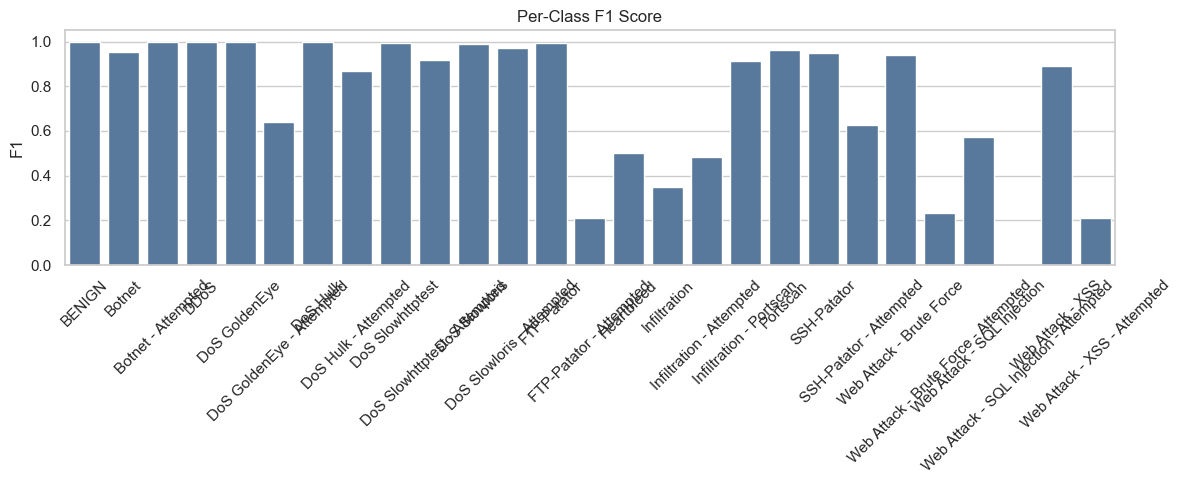

In [5]:
labels = list(range(num_classes))
report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
class_report = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
display(class_report.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}))

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = class_report.reset_index().rename(columns={"index": "Class", "f1-score": "F1"})
sns.barplot(data=plot_df, x="Class", y="F1", ax=ax, color="#4C78A8")
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1 Score")
ax.set_xlabel("")
ax.set_ylabel("F1")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## 5. Confusion Matrix

Rows are true labels and columns are predicted labels. The normalized view makes rare class mistakes easier to see.

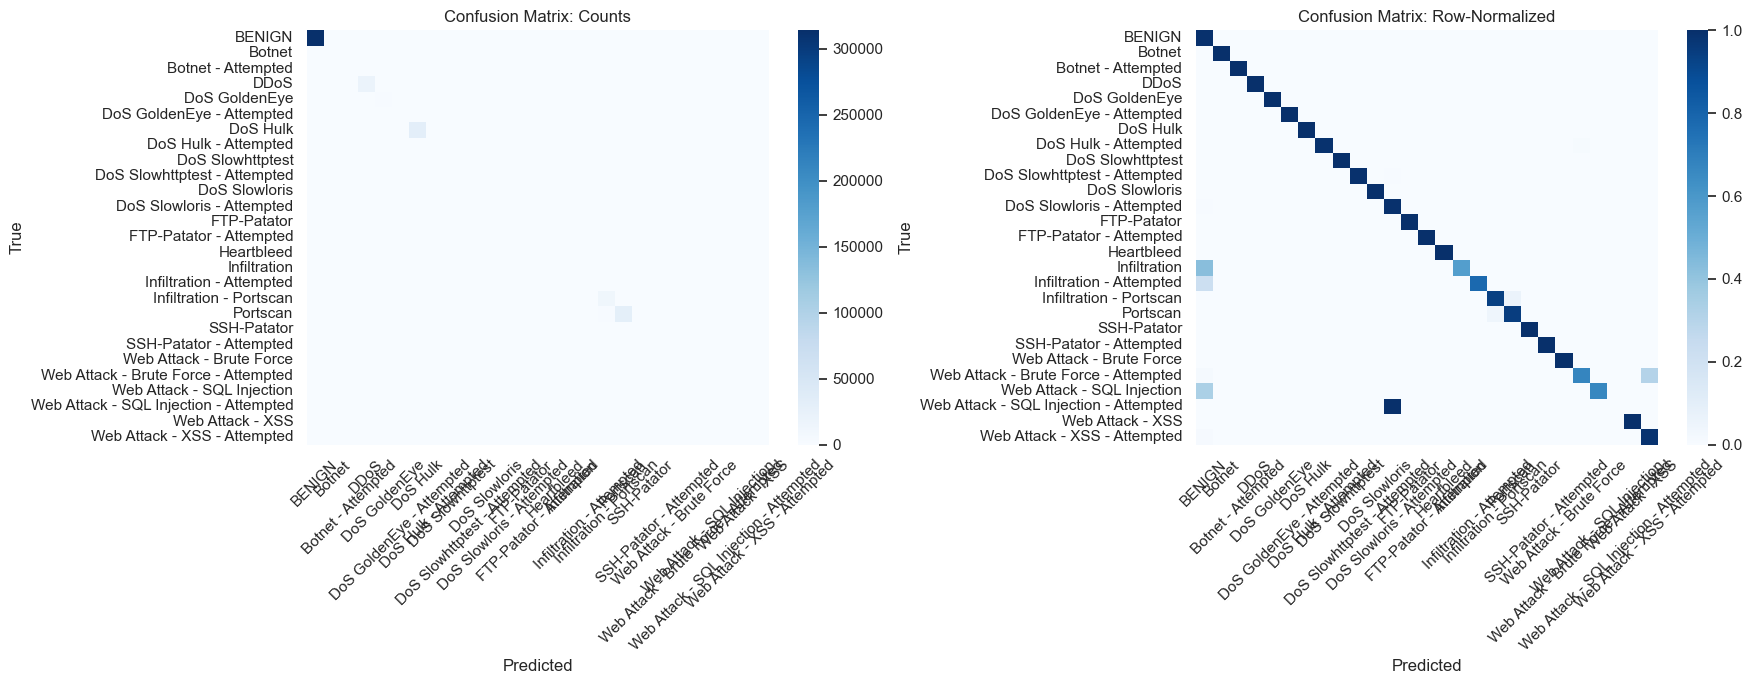

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, cmap="Blues", ax=axes[0], xticklabels=class_names, yticklabels=class_names, cbar=True)
axes[0].set_title("Confusion Matrix: Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, cmap="Blues", vmin=0, vmax=1, ax=axes[1], xticklabels=class_names, yticklabels=class_names, cbar=True)
axes[1].set_title("Confusion Matrix: Row-Normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()

## 6. IDS Binary View: Benign vs Attack

For deployment, it is useful to collapse all attack classes into one Attack group and inspect false alarms and missed attacks.

,Metric,Score,Meaning
0,False Positive Rate,0.0077,Benign traffic incorrectly flagged as attack
1,Attack Detection Recall,0.9995,Attack traffic correctly detected
2,Missed Attack Rate,0.0005,Attack traffic predicted as benign


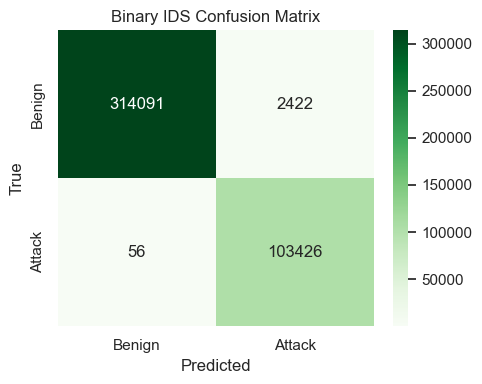

In [7]:
benign_idx = 0
if "BENIGN" in class_names:
    benign_idx = class_names.index("BENIGN")

y_attack_true = (y_true != benign_idx).astype(int)
y_attack_pred = (y_pred != benign_idx).astype(int)
binary_cm = confusion_matrix(y_attack_true, y_attack_pred, labels=[0, 1])
tn, fp, fn, tp = binary_cm.ravel()
fpr = fp / (fp + tn) if (fp + tn) else 0.0
attack_recall = tp / (tp + fn) if (tp + fn) else 0.0

binary_metrics = pd.DataFrame(
    [
        ["False Positive Rate", fpr, "Benign traffic incorrectly flagged as attack"],
        ["Attack Detection Recall", attack_recall, "Attack traffic correctly detected"],
        ["Missed Attack Rate", 1 - attack_recall, "Attack traffic predicted as benign"],
    ],
    columns=["Metric", "Score", "Meaning"],
)
display(binary_metrics.style.format({"Score": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(binary_cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"], ax=ax)
ax.set_title("Binary IDS Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()

## 7. Confidence and Error Analysis

This helps explain whether mistakes are low-confidence boundary cases or confident misclassifications.

,True,Predicted,Errors,Mean_confidence
38,Portscan,Infiltration - Portscan,1608,0.736
20,BENIGN,Web Attack - Brute Force - Attempted,1068,0.777
23,BENIGN,Web Attack - XSS - Attempted,897,0.560
36,Infiltration - Portscan,Portscan,856,0.692
7,BENIGN,DoS Slowhttptest - Attempted,113,0.959
43,Web Attack - Brute Force - Attempted,Web Attack - XSS - Attempted,79,0.592
15,BENIGN,Infiltration - Portscan,70,0.745
17,BENIGN,SSH-Patator,61,0.827
5,BENIGN,DoS Hulk - Attempted,34,0.783
16,BENIGN,Portscan,25,0.829


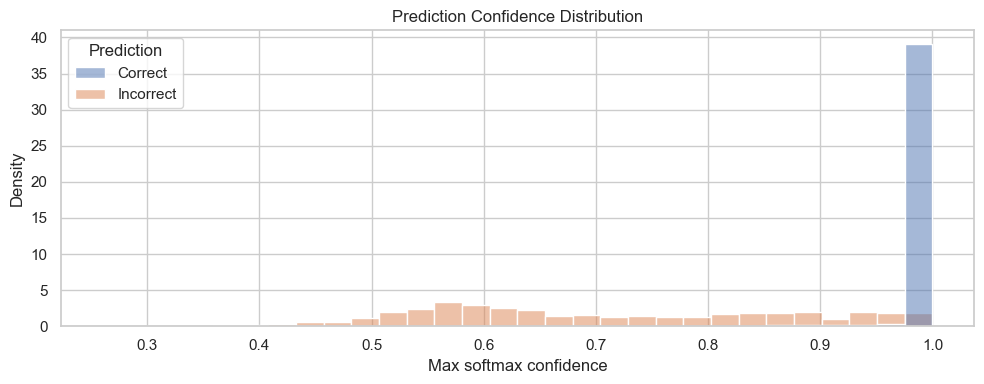

In [8]:
correct = y_true == y_pred
confidence_df = pd.DataFrame({"Max softmax confidence": max_conf, "Prediction": np.where(correct, "Correct", "Incorrect")})

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=confidence_df, x="Max softmax confidence", hue="Prediction", bins=30, stat="density", common_norm=False, ax=ax)
ax.set_title("Prediction Confidence Distribution")
plt.tight_layout()

errors = pd.DataFrame({
    "True": [class_names[i] if i < len(class_names) else str(i) for i in y_true[~correct]],
    "Predicted": [class_names[i] if i < len(class_names) else str(i) for i in y_pred[~correct]],
    "Confidence": max_conf[~correct],
})
pair_counts = errors.groupby(["True", "Predicted"]).agg(Errors=("Confidence", "size"), Mean_confidence=("Confidence", "mean")).reset_index()
display(pair_counts.sort_values("Errors", ascending=False).head(15).style.format({"Mean_confidence": "{:.3f}"}))

## Teacher Talking Points

- This is a centralized baseline, so it proves the MLP can learn the preprocessed feature space before federated learning is added.
- Accuracy should be interpreted together with Macro F1 because class imbalance is severe.
- The confusion matrix shows which attacks are confused with benign traffic or with each other.
- The binary IDS view reports false alarms and missed attacks in operational terms.
- The federated experiments should compare against this baseline and then against FedAvg/robust aggregators.